# Two-layered model validation

Validates the FEM solver against two-layer semi-analytical reference (eps_r = 4 / 9).

In [1]:
import sys, os

# ── locate master\ from examples\<name>\ (two levels up) ─────────────────
MASTER = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..')) # need to fix
print(f"Master directory: {MASTER}")

sys.path.insert(0, os.path.join(MASTER, 'io'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'inputs'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'outputs'))

# inputs
from survey import GPRSurvey

# runner
from runner import ProjectPaths, run_tetgen, run_solver

# outputs
from fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from postprocess import field_error, all_errors, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)


Master directory: f:\Projects\EMGeoInversion\elfe3D_GPR


---
## Paths

In [2]:
# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running from inside WSL
)

print('master   :', MASTER)
print('exec     :', paths.exec_path())


master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

In [3]:
f    = 100e6
wave = 3e8 / f     # 3.0 m in air;  lambda_2 = wave / sqrt(9) = 1.0 m in layer 2

BASE_DIR = os.path.join(MASTER, 'elfe3D_GPR')

survey = GPRSurvey.build(
    experiment_name = 'two_layered_earth',
    base_dir        = BASE_DIR,

    # Domain  (z goes down to just past second layer + PML)
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-1.0 - wave/10/3, wave/10],

    # Materials — air + 2 earth layers
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    layer_thicknesses = [1.0,    wave/10/3],   # layer 1: 1 m,  layer 2: thin half-space
    layer_eps_r       = [4.0,    9.0],
    layer_sigma       = [1e-4,   1e-3],
    layer_mu_r        = [1.0,    1.0],
    layer_sigma_m     = [0.0,    0.0],

    # Source
    ricker_central_f    = f,
    num_points_per_range = 1,
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1 + 0.75, 1 + 0.375],

    # Receivers
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 10,
)

survey.generate()
print('poly :', survey.io.poly_file)


odepths: [0.075, 0.0375, 0.025]
Source antenna length: 0.0006 m
Receiver antenna depth: -0.00015 m
[0.0, -1.0]
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_two_layered_earth.poly
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_two_layered_earth.poly


---
## 2 — Mesh with TetGen

In [4]:
run_tetgen(paths, survey.io.poly_file)

── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_two_layered_earth.poly

Opening GPR_model_two_layered_earth.poly.
Delaunizing vertices...
Delaunay seconds:  0.003053
Creating surface mesh ...
Surface mesh seconds:  0.001308
Constrained Delaunay...
Constrained Delaunay seconds:  0.001643
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000166
Refining mesh...
Refinement seconds:  0.814285
Optimizing mesh...
Optimization seconds:  0.044129

Writing GPR_model_two_layered_earth.1.node.
Writing GPR_model_two_layered_earth.1.ele.
Writing GPR_model_two_layered_earth.1.face.
Writing GPR_model_two_layered_earth.1.edge.
Writing GPR_model_two_layered_earth.1.vtk.
Writing GPR_model_two_layered_earth.1.neigh.

Output seconds:  0.716101
Total running seconds:  1.58088

Statistics:

  Input points: 242
  Input facets: 127
  Input segments: 369
  

---
## 3 — Run solver

In [5]:
run_solver(paths,survey)

── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_two_layered_earth.                   
Your mesh has
       42657 Nodes
      255939 Elements
      302011 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

---
## 4 — Load results

In [6]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D  layered',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_two_layered_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


---
## 5 — Analytical reference

In [7]:
# Two-layer Evert reference  (eps_r = 4 / 9)
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_9_100MHz_NR.csv'),
    label='Semi-Analytical',
).endfire()


---
## 6 — Comparison plot

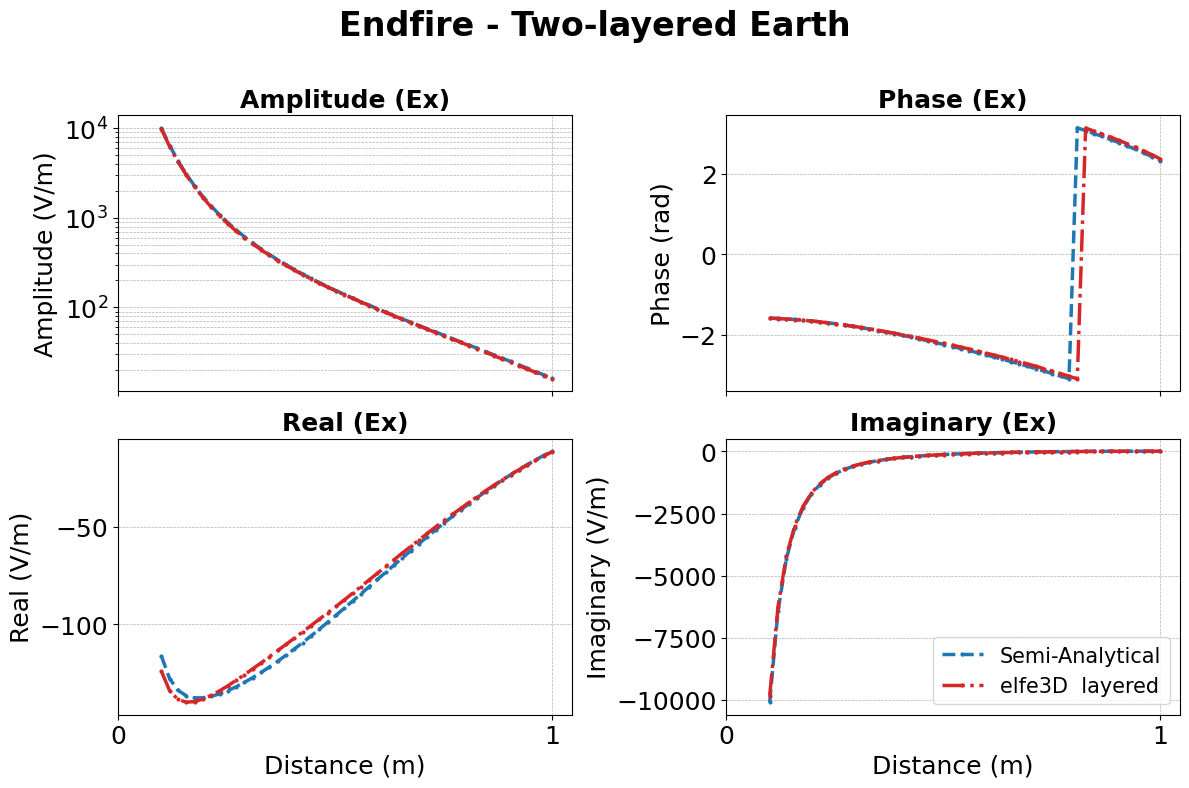

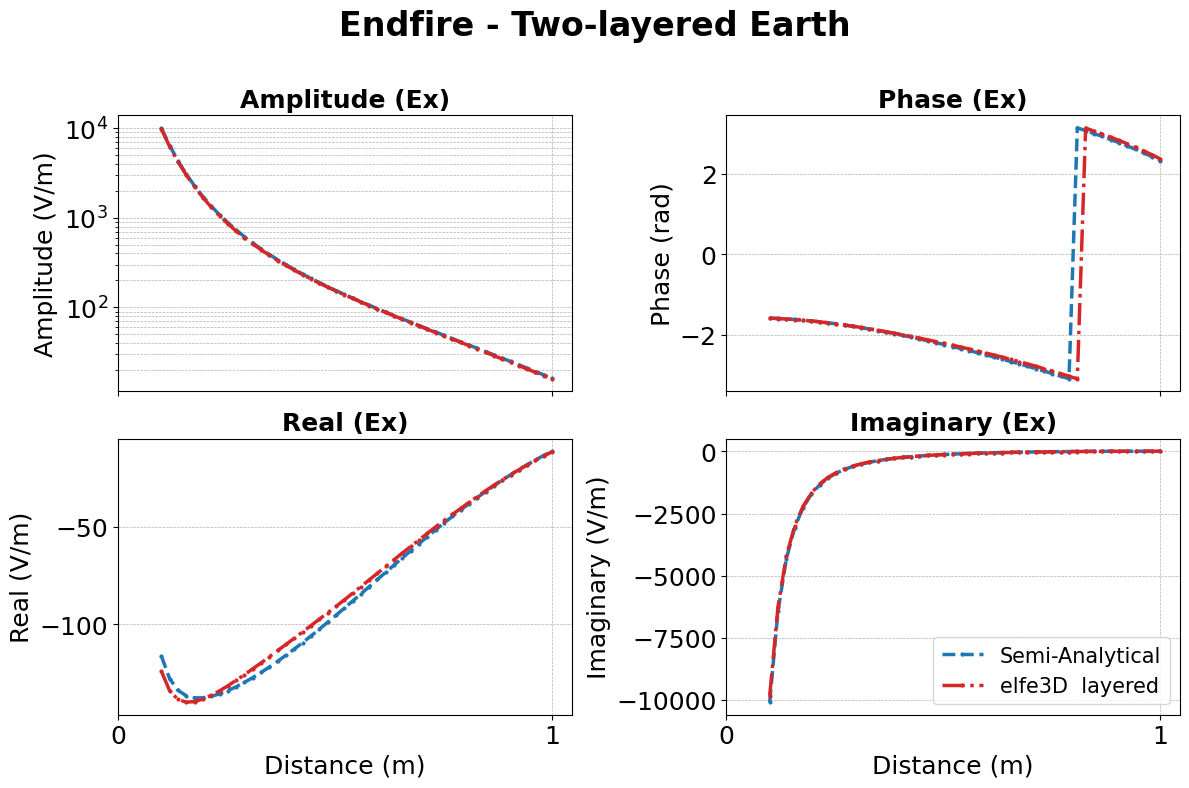

In [8]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Two-layered Earth")

## Error plot

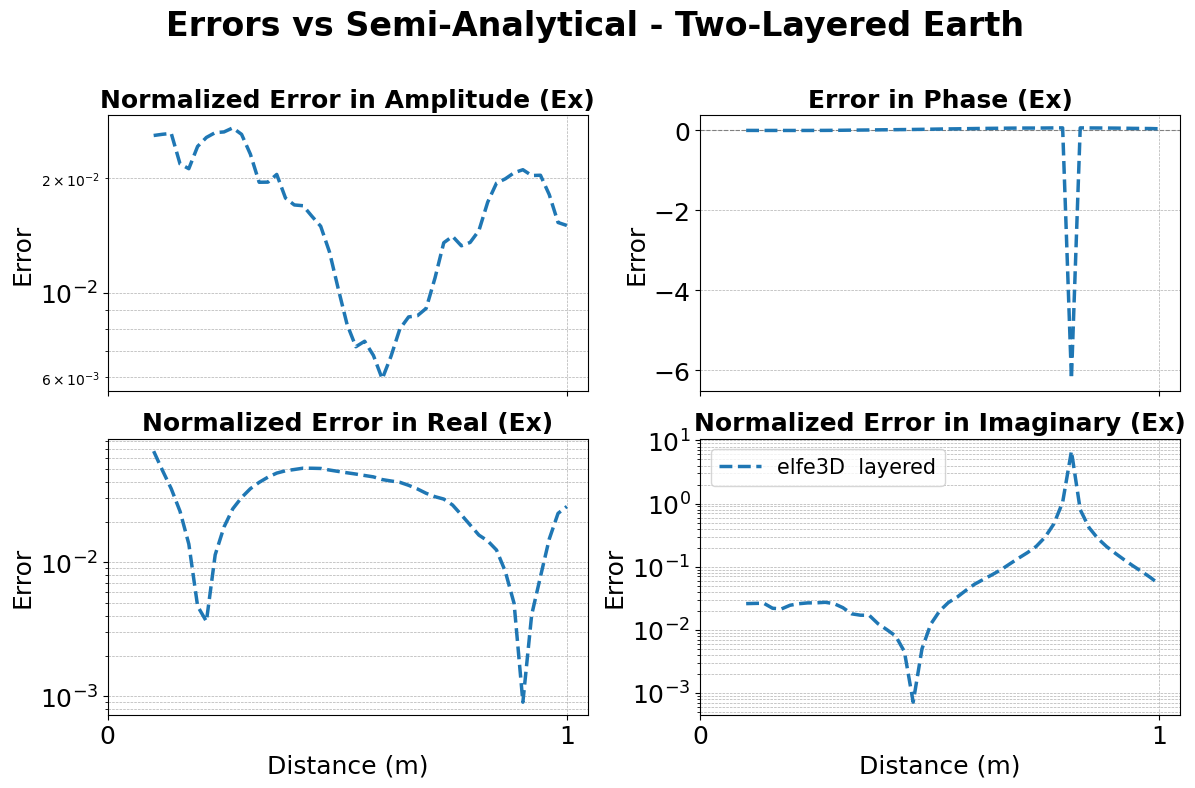

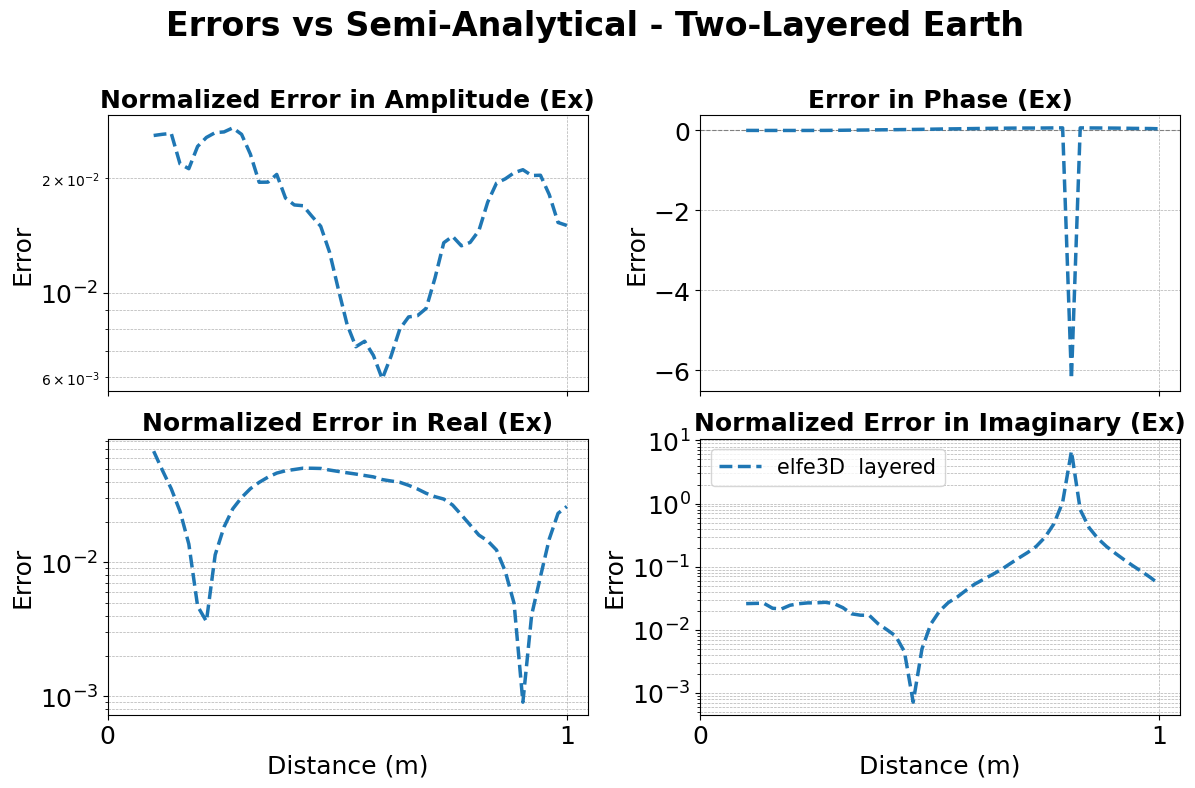

In [9]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Two-Layered Earth")

## Combined (fields + errors)

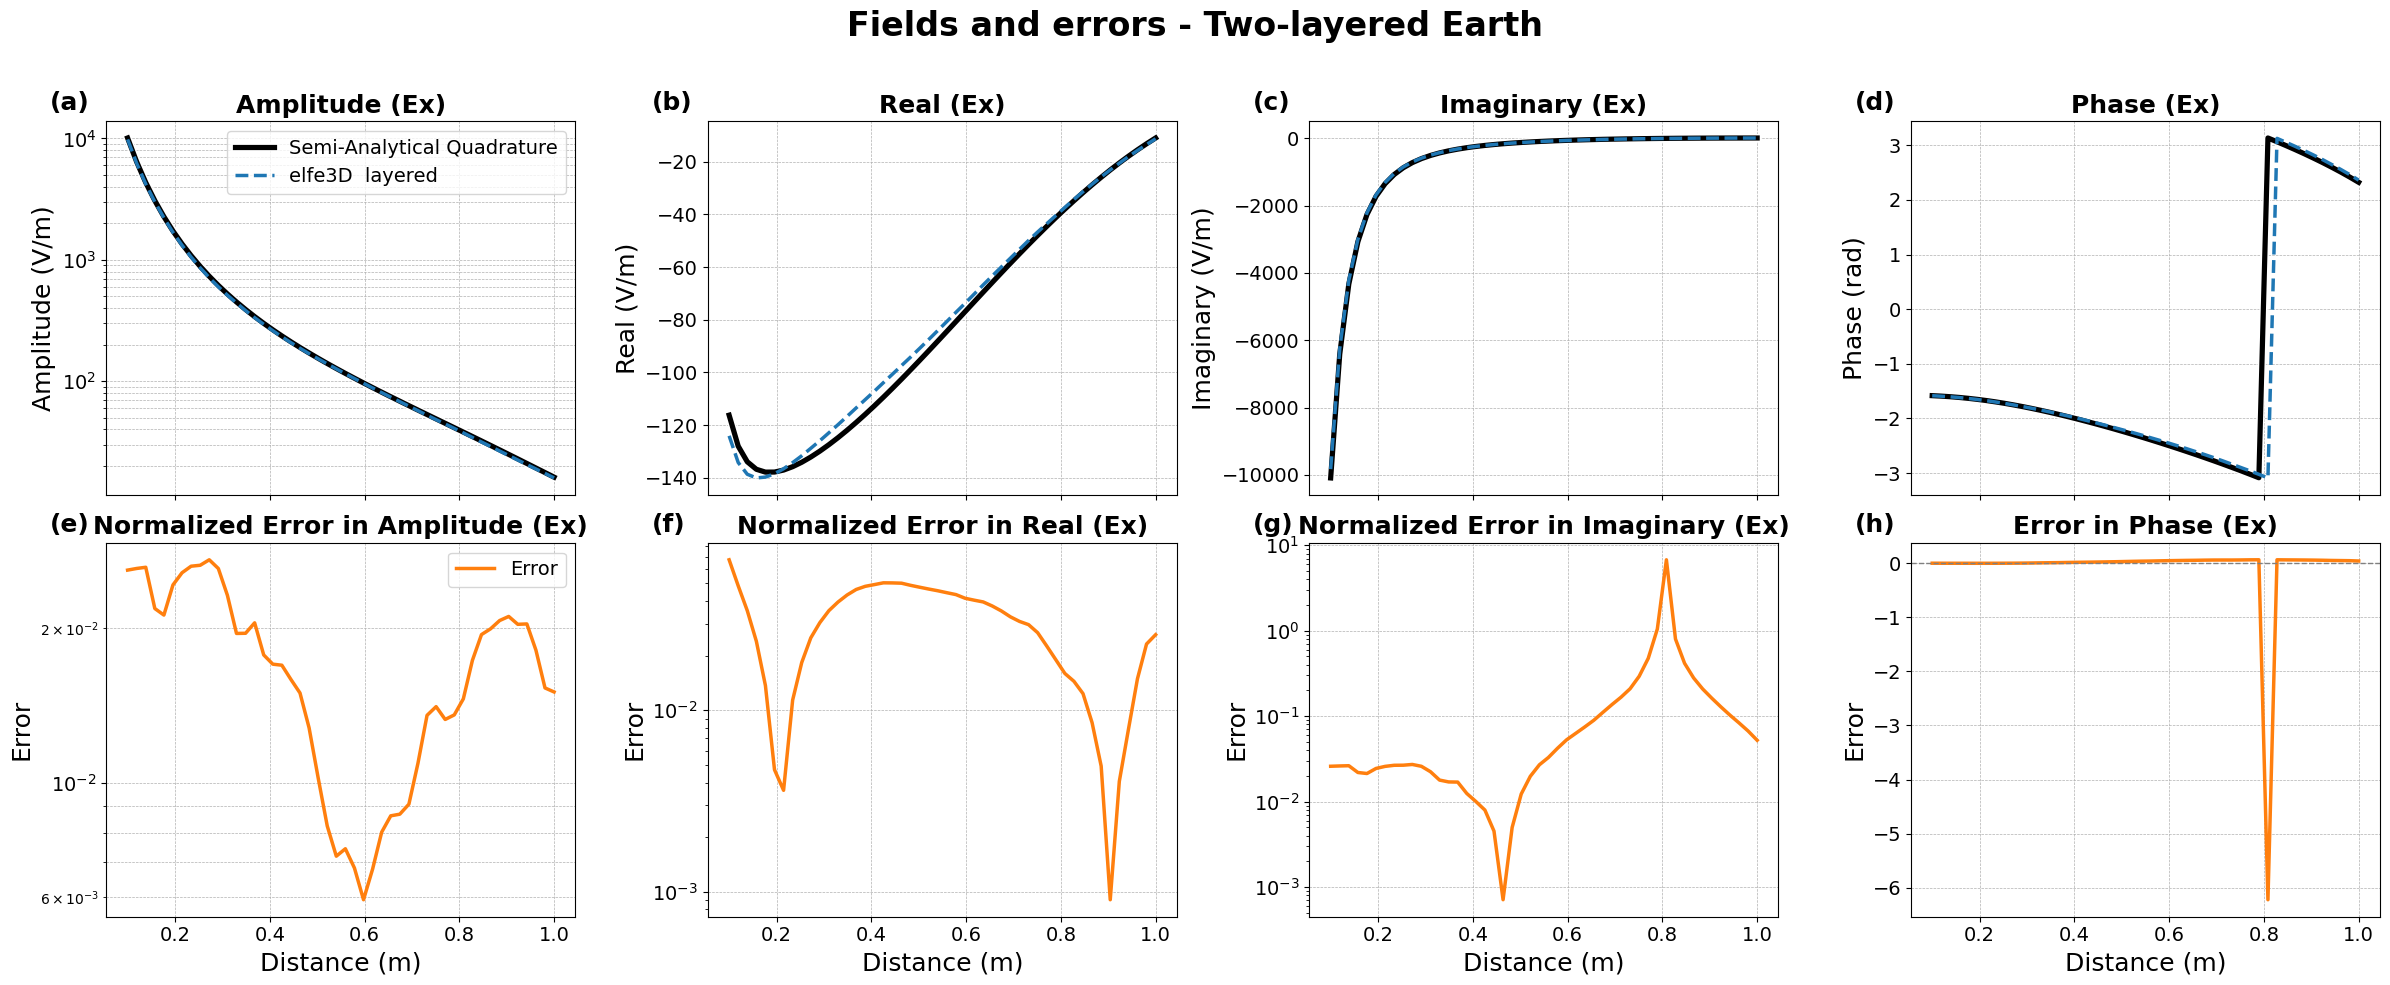

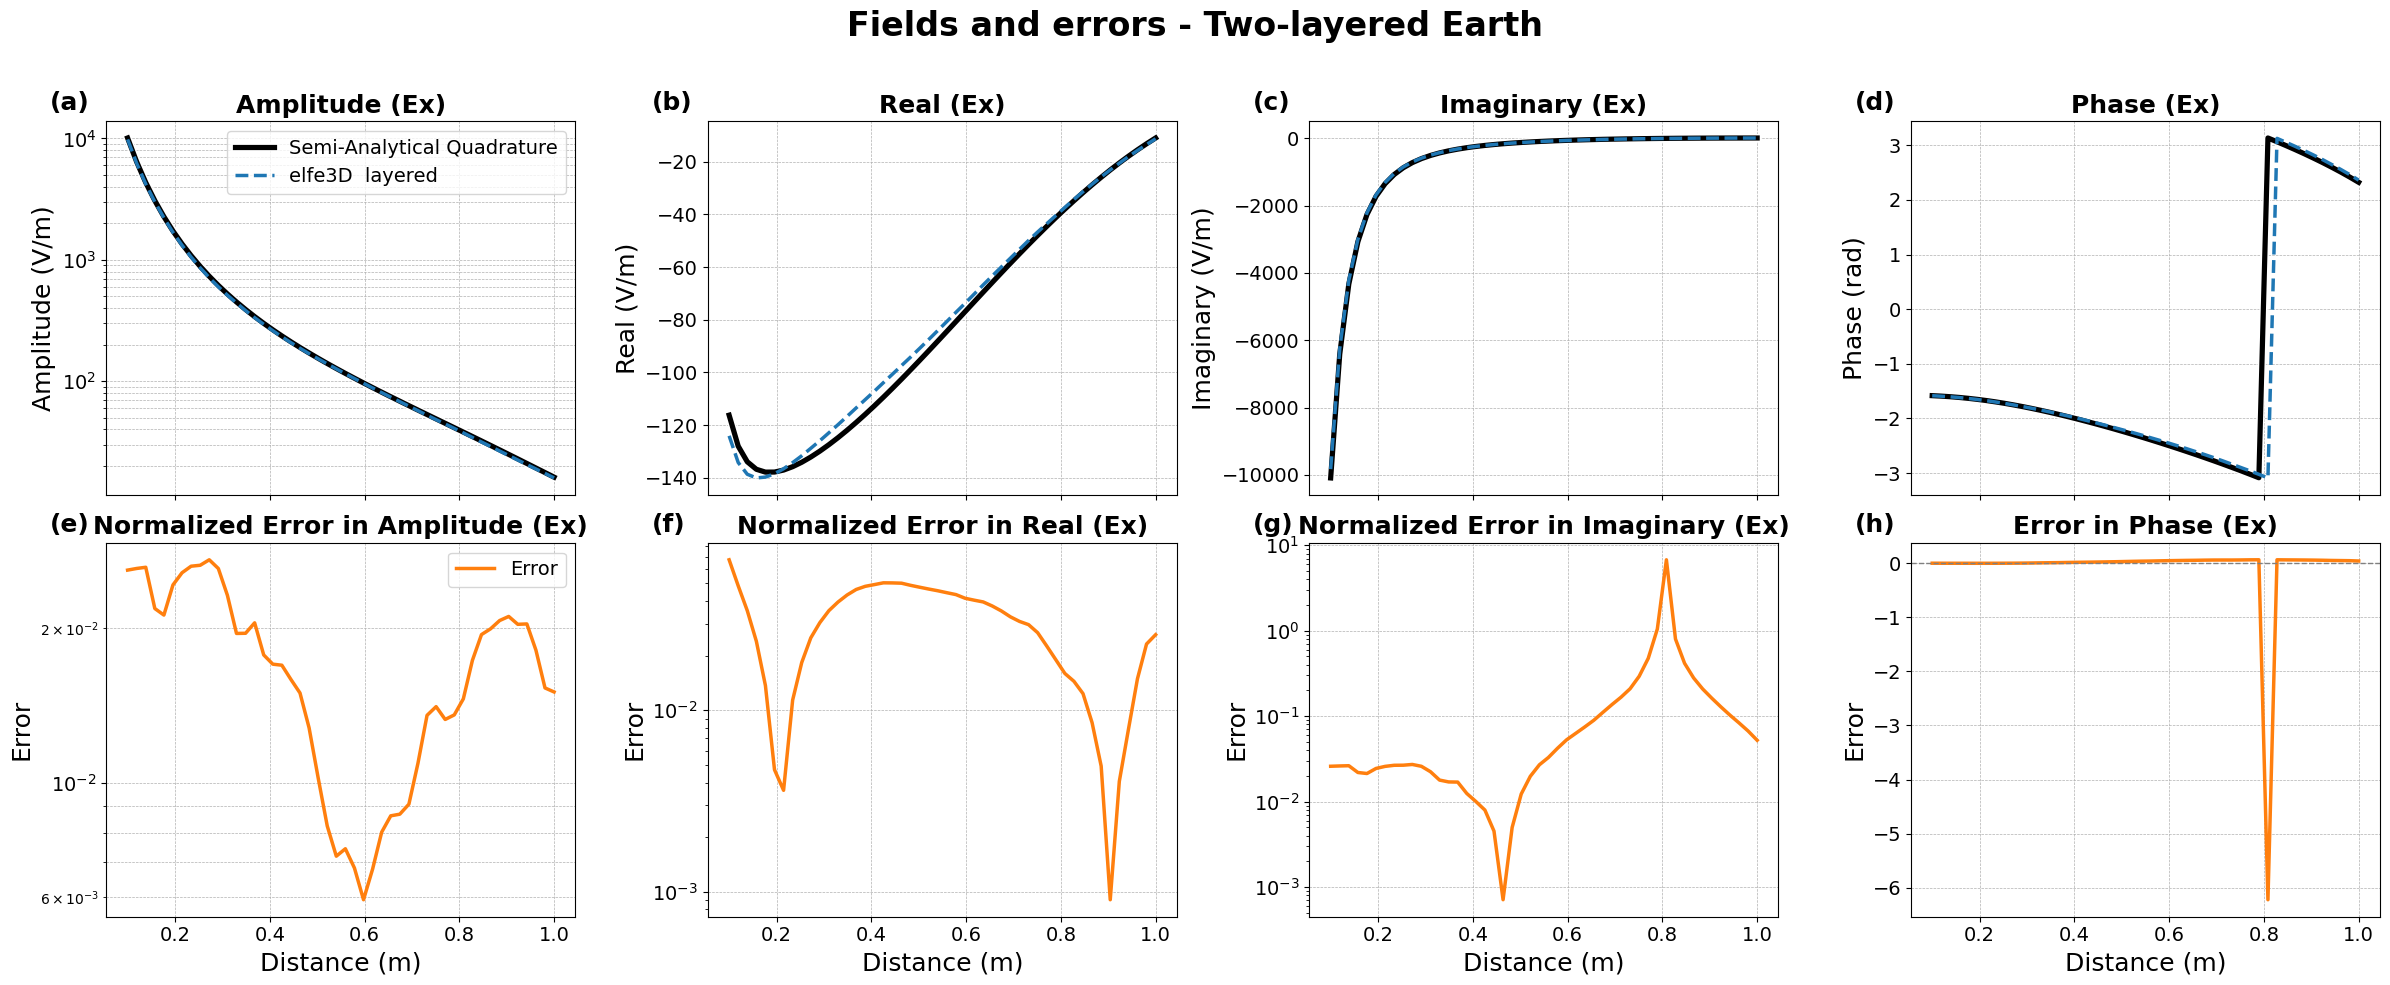

In [10]:
ReceiverLineCombined(ef, semi_analytical).plot(suptitle="Fields and errors - Two-layered Earth")

## Error histogram

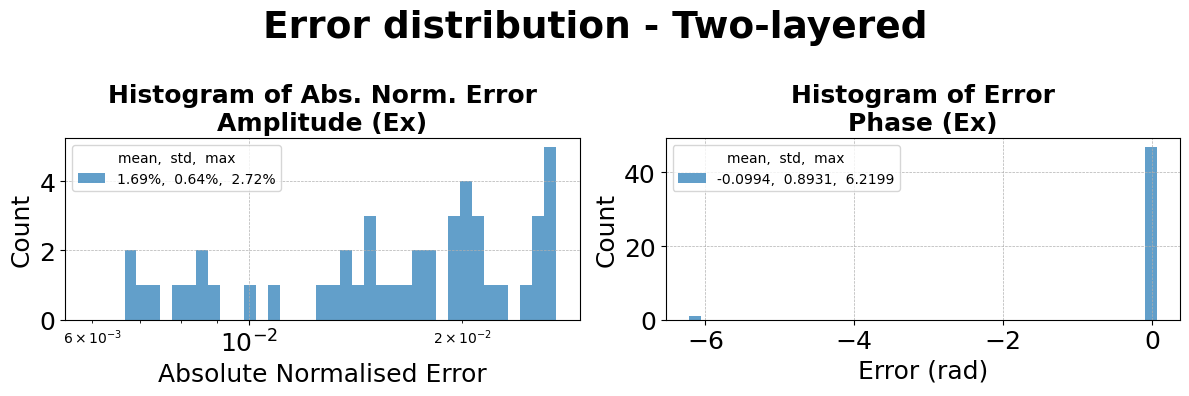

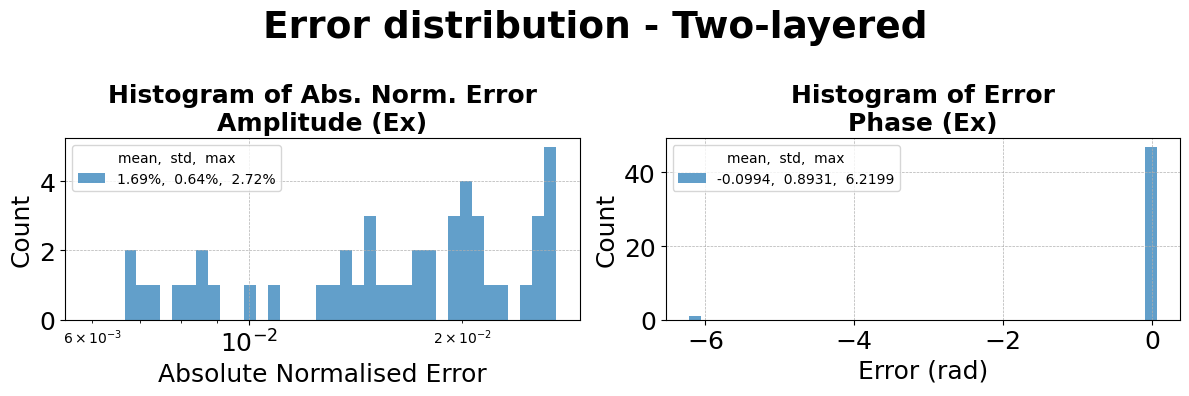

In [11]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle="Error distribution - Two-layered")

## Printed error summary

In [12]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print(f'\n── {ef.label} ──')
for qi, name in enumerate(qty_names):
    err = field_error(semi_analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')



── elfe3D  layered ──
  Amplitude   :  mean=1.688%  std=0.638%  max=2.716%
  Phase       :  mean=-0.099rad  std=0.893rad  max=6.220rad
  Real        :  mean=3.045%  std=1.630%  max=6.753%
  Imaginary   :  mean=25.655%  std=96.992%  max=676.513%


---
## 7 — PML thickness sweep

Runs the same two-layer model for several PML thicknesses expressed as $\lambda_2 / n$ where $\lambda_2$ is the wavelength in the second layer. Builds a separate `GPRSurvey` for each case so every run is fully reproducible.

**Run sections 7a-7c in order.  Once the runs are done, comment out 7b and jump straight to 7c to reload and replot.**

### 7a — Set up sweep surveys

In [13]:
from visualize import ErrorStatPlot

# Sweep over PML thickness expressed as a fraction of lambda_2
# lambda_2 = wave / sqrt(eps_r_layer2) = 3.0 / 3.0 = 1.0 m
wave2  = 3e8 / (100e6 * 3.0)   # 1.0 m

denoms = [10, 12.5, 15, 17.5, 20, 22.5, 25]

# Each entry will be a separate survey with a different pml_layer_thickness
sweep_surveys = []
for d in denoms:
    s = GPRSurvey.build(
        experiment_name     = f'tl_pml_{str(d).replace(".", "p")}',
        base_dir            = os.path.join(MASTER, 'io', 'inputs'),
        x_e = [-wave/10, 1 + wave/10],
        y_e = [-wave/10,     wave/10],
        z_e = [-1.0 - wave/10/3, wave/10],
        air_eps_r = 1.0,  air_sigma = 1e-16,
        layer_thicknesses = [1.0, wave/10/3],
        layer_eps_r  = [4.0,  9.0],
        layer_sigma  = [1e-4, 1e-3],
        layer_mu_r   = [1.0,  1.0],
        layer_sigma_m= [0.0,  0.0],
        ricker_central_f    = f,
        num_points_per_range = 1,
        antenna_position    = [0.0, 0.0, 0.025],
        source_type=6, current_direction=1, num_segments=1,
        s_f=250, bh_f=1.0, box_present=False, box_x=[-1+0.75, 1+0.375],
        num_receivers_inline=48,
        solver_type=2, max_ref_steps=0, max_unknowns=5_000_000,
        accuracy_tol=3e-5, output_fields_vtk=1,
        num_pml_layers=1,
        pml_layer_thickness = wave2 / d,
        pml_type='lin', pml_decay_type=1,
        least_samples_per_wavelength=20,
    )
    sweep_surveys.append(s)

print(f'Prepared {len(sweep_surveys)} sweep cases')
for s in sweep_surveys:
    print(f'  {s.io.experiment_name}  pml = {s.pml.layer_thickness:.4f} m')


odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
odepths: [0.0375, 0.01875, 0.0125]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Prepared 7 sweep cases
  tl_pml_10  pml = 0.1000 m
  tl_pml_12p5  pml = 0.0800 m
  tl_pml_15  pml = 0.0667 m
  tl_pml_17p5  pml = 0.0571 m
  tl_pml_20  pml = 0.0500 m
  tl_pml_22p5  pml = 0.0444 m
  tl_pml_25  pml = 0.0400 m


### 7b — Run each case  *(comment out once done)*

In [14]:
# ── write inputs, mesh and solve each sweep case ───────────────────────────
# Comment out once the runs are done; re-run only to regenerate.
for s in sweep_surveys:
    print(f'\n>>> {s.io.experiment_name}')
    s.generate()
    run_tetgen(paths, s.io.poly_file)
    run_solver(paths, s)



>>> tl_pml_10
[0.0, -1.0]
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\io\inputs\in\GPR_model_tl_pml_10.poly
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\io\inputs\in\elfe3D_input.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\io\inputs\in\source.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\io\inputs\in\regionparameters.txt
Input generation complete.
── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/io/inputs/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_tl_pml_10.poly

Opening GPR_model_tl_pml_10.poly.
Delaunizing vertices...
Delaunay seconds:  0.005195
Creating surface mesh ...
Surface mesh seconds:  0.001693
Constrained Delaunay...
Constrained Delaunay seconds:  0.0014
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000191
Refining mesh...
Refinement seconds:  1.61845
Optimizing mesh...
Optimization seconds:  0.069829

Writing GPR_model_tl_pml_10.1.node.
Writing GPR_mode

### 7c — Load results and plot

In [15]:
sweep_datasets = []
for s, d in zip(sweep_surveys, denoms):
    result_txt = s.io.output_dir / 'electric_fields_receiver_line.txt'
    ds = ElfeLoader(
        filepath    = str(result_txt),
        label       = rf'$\lambda_2/{d}$',
        num_endfire = 48,
    ).endfire()
    sweep_datasets.append(ds)

print(f'Loaded {len(sweep_datasets)} sweep datasets')


Loaded 7 sweep datasets


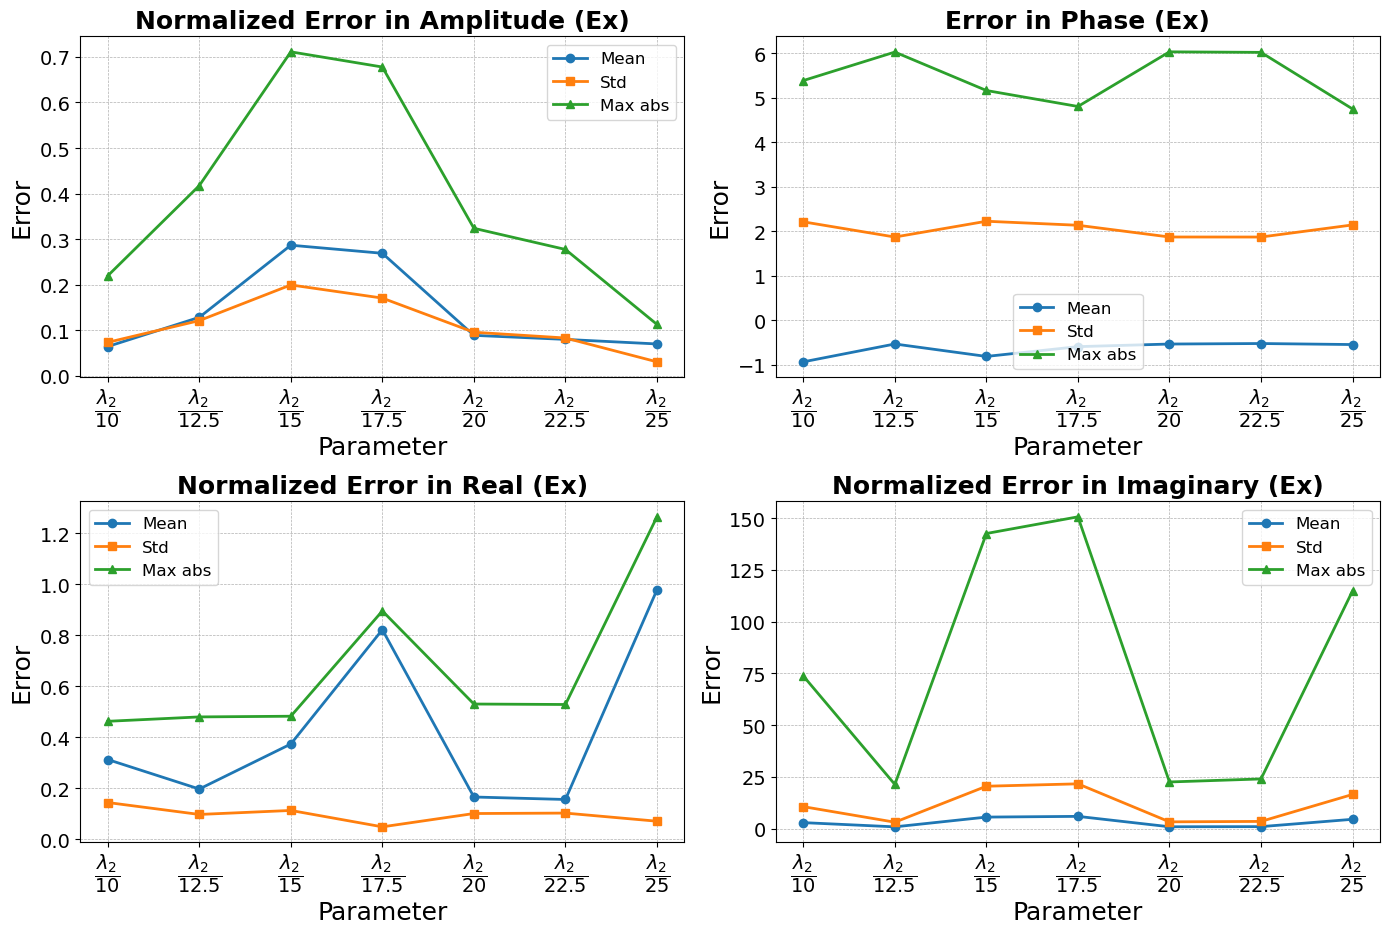

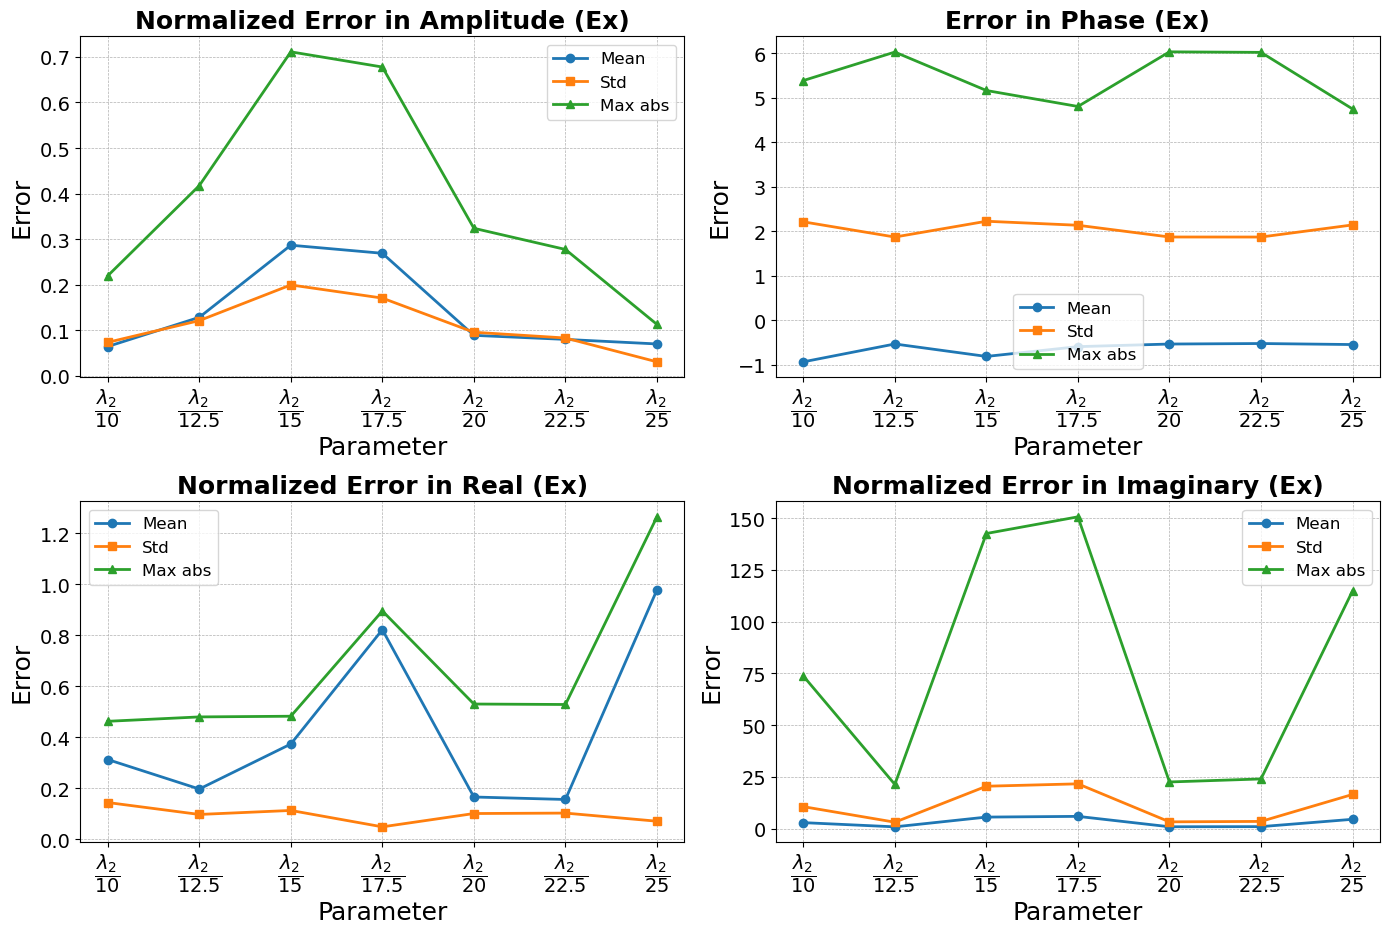

In [17]:
xtick_labels = [rf'$\dfrac{{\lambda_2}}{{{d}}}$' for d in denoms]

ErrorStatPlot(
    sweep_datasets,
    reference    = semi_analytical,
    param_values = [wave2 / d for d in denoms],
    xtick_labels = xtick_labels,
).plot()


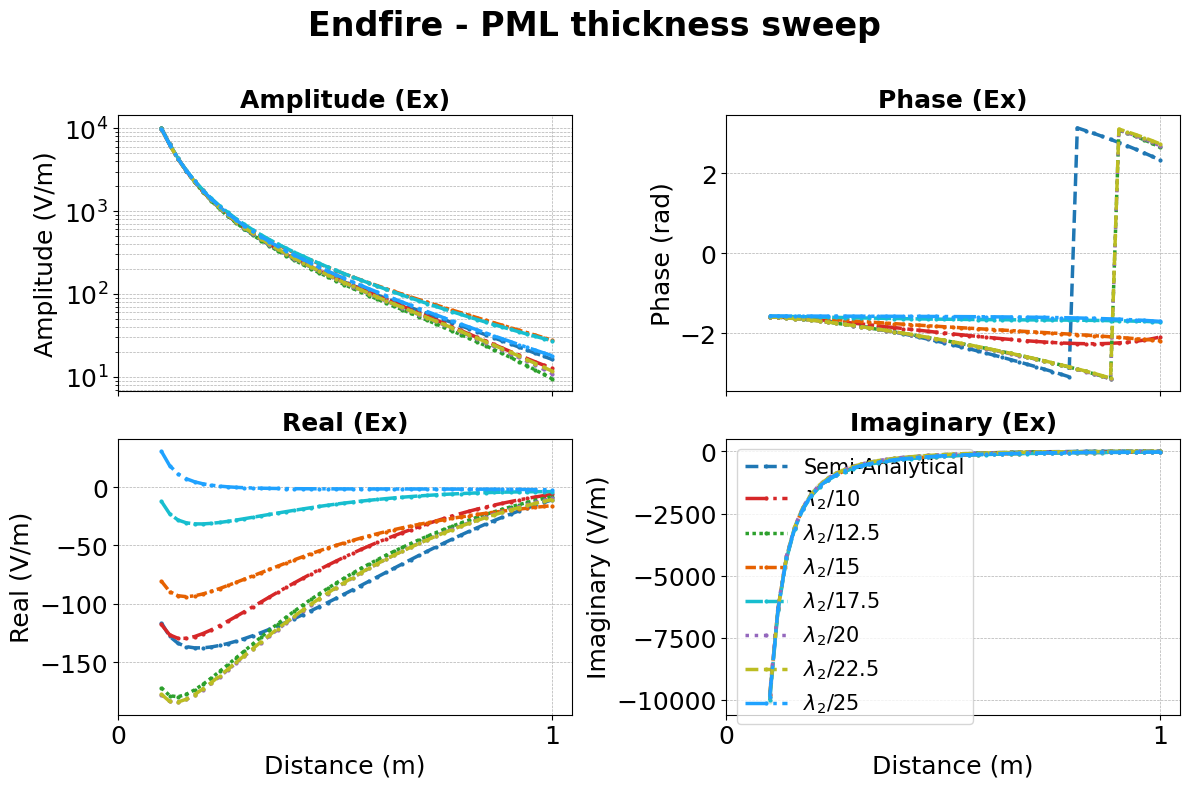

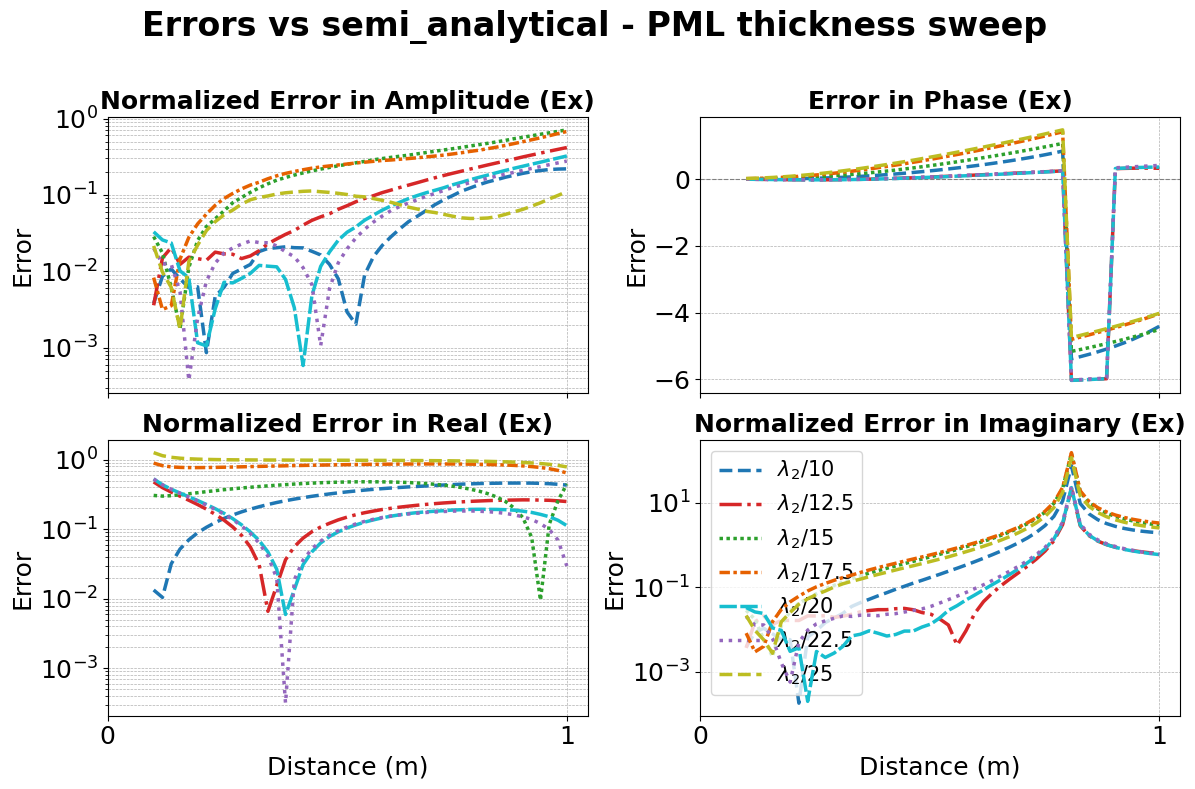

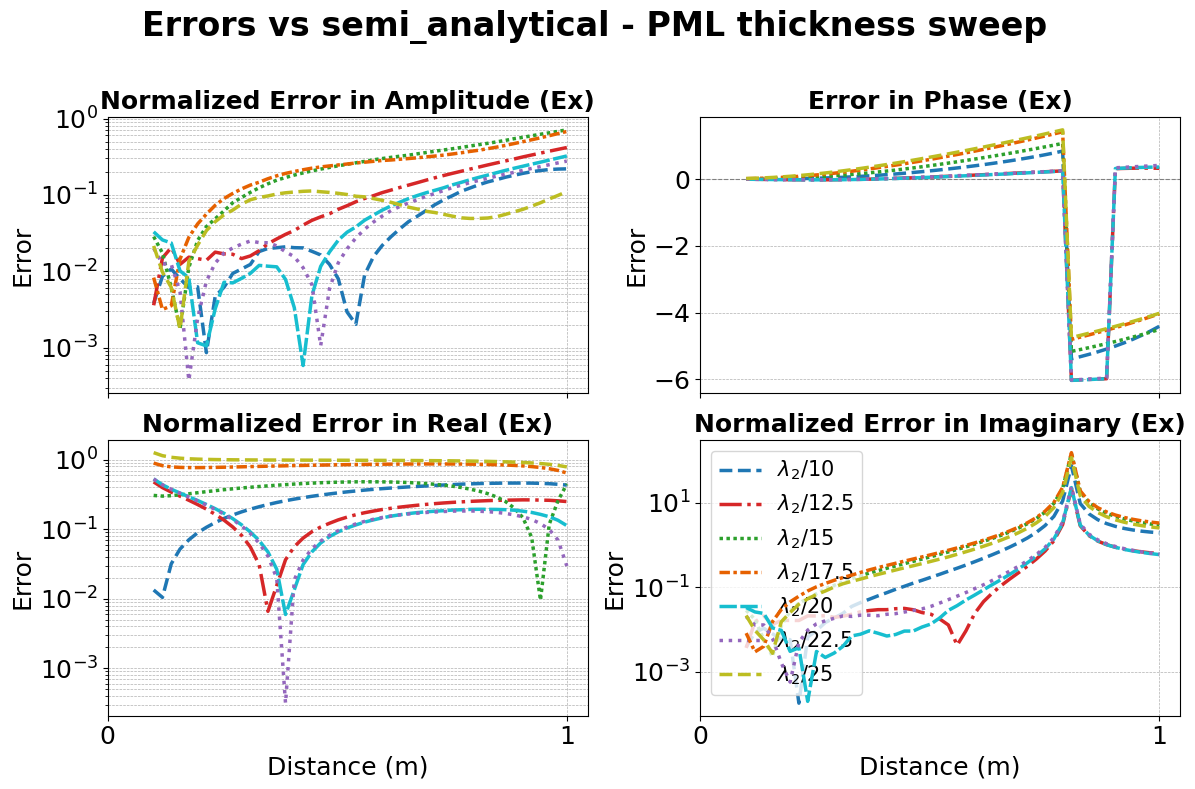

In [22]:
# All sweep runs on one comparison and one error plot
ReceiverLinePlot([semi_analytical] + sweep_datasets).plot(suptitle='Endfire - PML thickness sweep')
ReceiverLineErrorPlot(sweep_datasets, reference=semi_analytical).plot(suptitle='Errors vs semi_analytical - PML thickness sweep')
